In [10]:
import tensorflow as tf
from tensorflow import keras
import os
import pandas as pd
from tensorflow.keras.applications import ResNet50V2
from sklearn.model_selection import StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from PIL import Image
import imageio
import sklearn
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, plot_precision_recall_curve, average_precision_score

In [3]:
baseline2 = keras.models.load_model('models/model_complete.h5')
baseline2.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 rescaling_2 (Rescaling)     (None, 256, 256, 3)       0         
                                                                 
 resnet50v2 (Functional)     (None, 8, 8, 2048)        23564800  
                                                                 
 global_average_pooling2d_2   (None, 2048)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_2 (Dense)             (None, 1)                 2049      
                                                                 
Total params: 23,566,849
Trainable params: 2,049
Non-trainable params: 23,564,800
___________________________________________

In [4]:
TRAIN_PATH = 'datasets/ISIC_2020_corrected/train_resized'
train_images = os.listdir(TRAIN_PATH)
img = Image.open(f'{TRAIN_PATH}/{train_images[0]}')
img.size


(256, 256)

In [5]:
PATH = 'datasets/ISIC_2020_corrected'
test = pd.read_csv(f'{PATH}/test_split.csv')
BATCH_SIZE = 64
AUTO = tf.data.experimental.AUTOTUNE

def decode(name, label):
    img = tf.io.read_file(name)
    img = tf.image.decode_jpeg(img, channels = 3)
    img = tf.cast(img, tf.float32)
    return img, label
    
def load_ds(df):
    options = tf.data.Options()
    options.experimental_deterministic = False
    imgs, labels = df["image_name"].values, df["target"].values
    imgs = [f'{PATH}/train_resized/{name}.jpg' for name in imgs]
    ds = tf.data.Dataset.from_tensor_slices((imgs, labels))
    ds = ds.with_options(options)
    ds = ds.map(decode, num_parallel_calls=AUTO)
    ds = ds.cache()
    ds = ds.shuffle(2048)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTO)
    return ds
test_ds = load_ds(test)
baseline2.evaluate(test_ds)

78/78 [==============================] - 21s 176ms/step - loss: 0.0723 - auc-ROC: 0.8538 - auc-PR: 0.1141


[0.0722556859254837, 0.853801429271698, 0.11406217515468597]

In [6]:
malignant = test.loc[test.index[test['target'] == 1]]
benign = test.loc[test.index[test['target'] == 0]]
malignant

,image_name,patient_id,lesion_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
208,ISIC_6971606,IP_9375901,IL_9213093,female,25.0,torso,melanoma,malignant,1
221,ISIC_8724944,IP_3089004,IL_7415900,female,45.0,torso,melanoma,malignant,1
227,ISIC_1255336,IP_7650895,IL_3080866,female,65.0,lower extremity,melanoma,malignant,1
278,ISIC_3023646,IP_6658881,IL_3206915,male,80.0,head/neck,melanoma,malignant,1
312,ISIC_2320481,IP_9205637,IL_1645335,male,65.0,torso,melanoma,malignant,1
...,...,...,...,...,...,...,...,...,...
4536,ISIC_0914168,IP_3659172,IL_7413123,female,50.0,torso,melanoma,malignant,1
4577,ISIC_8866651,IP_8375879,IL_4249218,male,75.0,torso,melanoma,malignant,1
4583,ISIC_7960321,IP_4327880,IL_7205523,male,75.0,torso,melanoma,malignant,1
4632,ISIC_3697702,IP_2809878,IL_9287863,female,45.0,torso,melanoma,malignant,1


In [7]:
predictions_df = pd.DataFrame({'image_name': [],
                               'target': [],
                               'prediction':[]})
for index, row in test.iterrows():
    name = row['image_name']
    image = imageio.v2.imread(f'{TRAIN_PATH}/{name}.jpg')
    image = np.expand_dims(image, axis=0)
    p = baseline2(image).numpy()[0][0]
    new_row = pd.DataFrame({'image_name':[name],
                          'target':[row['target']],
                          'prediction':[p]})
    predictions_df = pd.concat([predictions_df, new_row])
    
predictions_df

,image_name,target,prediction
0,ISIC_0384200,0.0,0.000945
0,ISIC_9512558,0.0,0.019156
0,ISIC_1474577,0.0,0.009801
0,ISIC_6100064,0.0,0.002274
0,ISIC_7406225,0.0,0.001244
...,...,...,...
0,ISIC_2596262,0.0,0.011491
0,ISIC_3484662,0.0,0.033017
0,ISIC_6977581,0.0,0.005420
0,ISIC_9257356,0.0,0.001499


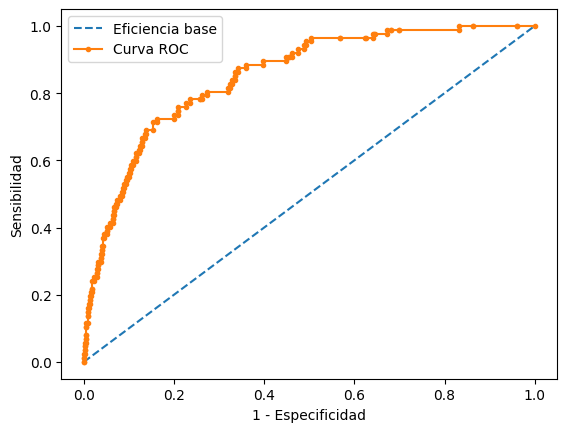

In [27]:
fpr, tpr, thresholds = roc_curve(predictions_df['target'],predictions_df['prediction'])
mpl.style.use('default')
plt.plot([0,1], [0,1], linestyle='--', label='Eficiencia base')
plt.plot(fpr, tpr, marker='.', label='Curva ROC')
# axis labels
plt.xlabel('1 - Especificidad')
plt.ylabel('Sensibilidad')
plt.legend()
# show the plot
plt.savefig('ROC curve', dpi=100)
plt.show()

In [16]:
gmeans = np.sqrt(tpr *(1-fpr))
ix = np.argmax(gmeans)
print('Best Threshold=%f, G-Mean=%.3f' % (thresholds[ix], gmeans[ix]))

Best Threshold=0.021065, G-Mean=0.779


In [17]:
roc_auc_score(predictions_df['target'],predictions_df['prediction'])

0.8508949130514629

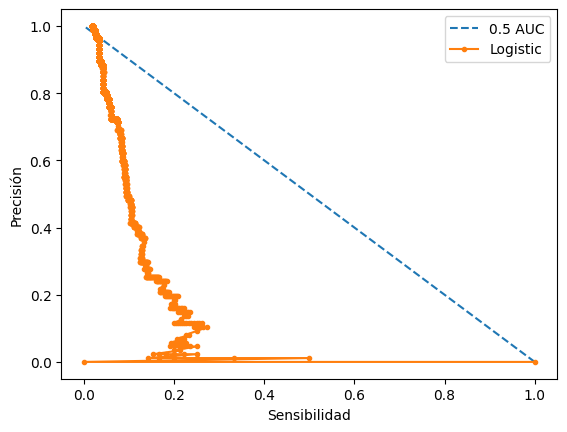

In [18]:
precision_, recall_, proba = precision_recall_curve(predictions_df['target'],predictions_df['prediction'])
plt.plot([1,0], [0,1], linestyle='--', label='0.5 AUC')
plt.plot(precision_, recall_, marker='.', label='Logistic')
# axis labels
plt.xlabel('Sensibilidad')
plt.ylabel('Precisión')
plt.legend()
# show the plot
plt.savefig('PR curve', dpi=100)
plt.show()

In [19]:
average_precision_score(predictions_df['target'],predictions_df['prediction'])

0.11985280884734391